### Notebook running Quantum State Tomography (QST) Algorithms
Algorithms implemented:
1) Maximum Likelihood Estimation (MLE)

In [ ]:
# Import Packages
import numpy as np
import matplotlib.pyplot as plt

import qutip as q
from tqdm.notebook import tqdm

####################################################################
# Import utilities
import sys
from pathlib import Path

root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))

from utilities.artificial_samples import cat, sqv, pssqv, spssqv, sample_homodyne
from utilities.MLE_class import MLE
from utilities.MLE_class_faster import MLE as MLE_f
from utilities.plotting import plot_dm, plot_Wigner, plot_fidelities

In [2]:
# Define target cat state parameters
N_cutoff = 50
parity = 0
theta = np.pi/4
alpha = np.sqrt(5)*np.exp(1j*theta)
# Generate target state
state = cat(N_cutoff, parity, alpha)

In [3]:
# Define target squeezed vacuum state parameters
N_cutoff = 50
r = 1.0
# Generate target state
state = sqv(N_cutoff, r)

In [4]:
# ON state parameters
N_cutoff = 50
n = 3
parity = 1
# Generate target state
ket = np.zeros(N_cutoff, dtype=complex)
ket[0] = 1/np.sqrt(2)
ket[n] = (-1)**parity / np.sqrt(2)
state = q.Qobj(ket)
rho = state.full()


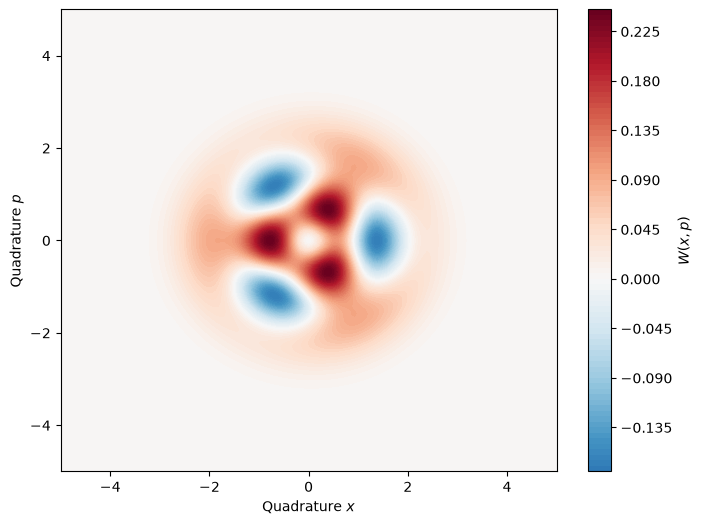

In [5]:
plot_Wigner(state)

In [5]:
# Define sampling parameters
N_angles = 8
N_samples_theta = 1000
x_range = (-5,5)
x_points = 400
x_array = np.linspace(x_range[0],x_range[1],x_points)
# Sample the selected state
thetas, samles = sample_homodyne(state=state,n_angles=N_angles,n_samples_theta=N_samples_theta,
                         bin_data=False,x_vec=x_array)

In [31]:
%load_ext line_profiler
# Test speed
n_bins = 20
n_iter = 50

rho_init = np.zeros((N_cutoff, N_cutoff), dtype=complex)
rho_init[0,0] = 1.0

# Initialize MLE estimator
MLE_estimator = MLE(data=samles, N_bins=n_bins, N_cutoff=N_cutoff)
MLE_estimator_f = MLE_f(data=samles, N_bins=n_bins, N_cutoff=N_cutoff)
%lprun -f MLE_estimator.run_ntimes MLE_estimator.run_ntimes(rho_init=rho_init, n_iterations=n_iter)

The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler


Timer unit: 1e-09 s

Total time: 1.50373 s
File: /home/lcgho/projects/QST/utilities/MLE_class_original.py
Function: MLE.run_ntimes at line 174

Line #      Hits         Time  Per Hit   % Time  Line Contents
   174                                               def run_ntimes(self, n_iterations, **kw):
   175         1 1503732558.0  1.5e+09    100.0          return self.run(max_iter=n_iterations, **kw)

In [13]:
# Set MLE parameters
N_bins_array = np.arange(5, 50, 5)
max_iter = 1000

rho_init = np.zeros((N_cutoff, N_cutoff), dtype=complex)
rho_init[0,0] = 1.0

# Arrays to store results
rhos = []
fidelities = []

# Initialize MLE estimator
MLE_estimator = MLE(data=samles, N_bins=N_bins_array[0], N_cutoff=N_cutoff)

for N_bins in N_bins_array:
    MLE_estimator.set_binning(N_bins)

    rho_current = rho_init
    rhos_bin = [rho_current]
    fidelities_bin = []
    rho_bin, fidelities_bin, rhos_bin = MLE_estimator.run_setpoint(threshold=1e-15,max_iter=max_iter,store_states=True)
    runs_bin = len(fidelities_bin)
    fid_bin = q.fidelity(q.Qobj(rho_bin),state)**2
    print(f'For {N_bins} bins: {runs_bin} iterations, f={fid_bin}')
    rhos.append(rhos_bin)
    fidelities.append(fidelities_bin)


For 5 bins: 371 iterations, f=0.8006284970697775
For 10 bins: 233 iterations, f=0.9540008024015642
For 15 bins: 145 iterations, f=0.9648861986460717
For 20 bins: 111 iterations, f=0.9615017982664384
For 25 bins: 135 iterations, f=0.9579186790344985
For 30 bins: 91 iterations, f=0.9593766215942348
For 35 bins: 94 iterations, f=0.9534697553589905
For 40 bins: 104 iterations, f=0.9606601983634216
For 45 bins: 98 iterations, f=0.9623935148350934


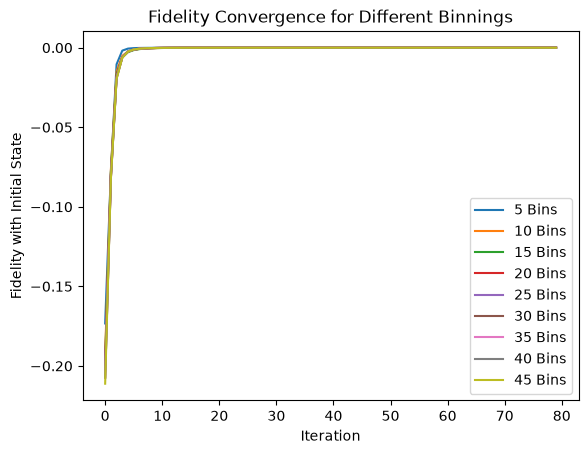

[[0.6709414710461951, 0.8348112206545701, 0.9762499890983338, 0.9957783573193301, 0.9986947453007003, 0.9993870148906613, 0.9996287983795021, 0.9997380325599196, 0.9997966812667468, 0.999832341814405, 0.9998561869122798, 0.9998733557587801, 0.9998864513586051, 0.999896900217449, 0.999905527381543, 0.9999128421308756, 0.9999191706514744, 0.999924734360238, 0.9999296810966566, 0.9999341263800298, 0.9999381478921404, 0.9999418112224211, 0.9999451655123509, 0.9999482471686211, 0.9999510906761127, 0.99995372140508, 0.9999561614287882, 0.9999584300988941, 0.9999605436093133, 0.9999625153887364, 0.9999643568162095, 0.9999660810972777, 0.9999676961807973, 0.9999692128831699, 0.9999706367641094, 0.9999719741048899, 0.9999732348290707, 0.9999744192455542, 0.9999755367916526, 0.9999765929136576, 0.999977588814335, 0.9999785305843734, 0.9999794193552004, 0.9999802610614281, 0.9999810585905666, 0.9999818145557926, 0.9999825303839266, 0.9999832100192266, 0.9999838557842184, 0.9999844679207138, 0.999

In [9]:
# Plot the fidelity convergence for each binning
for i, N_bins in enumerate(N_bins_array):
    plt.plot(np.log10(fidelities[i][:80]), label=f'{N_bins} Bins')
plt.xlabel('Iteration')
plt.ylabel('Fidelity with Initial State')
plt.title('Fidelity Convergence for Different Binnings')
plt.legend()
plt.show()
print(fidelities)

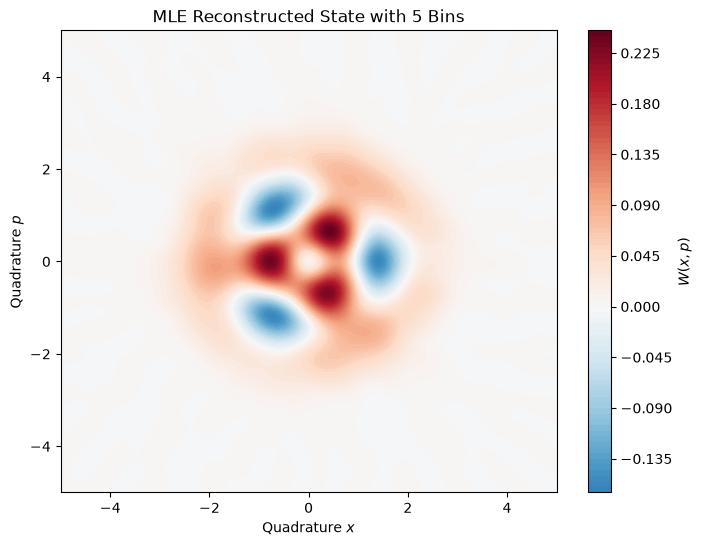

In [10]:
plot_Wigner(q.Qobj(rhos[1][-1]), xvec=x_array, title='MLE Reconstructed State with 5 Bins')

  0%|          | 0/100 [00:00<?, ?it/s]

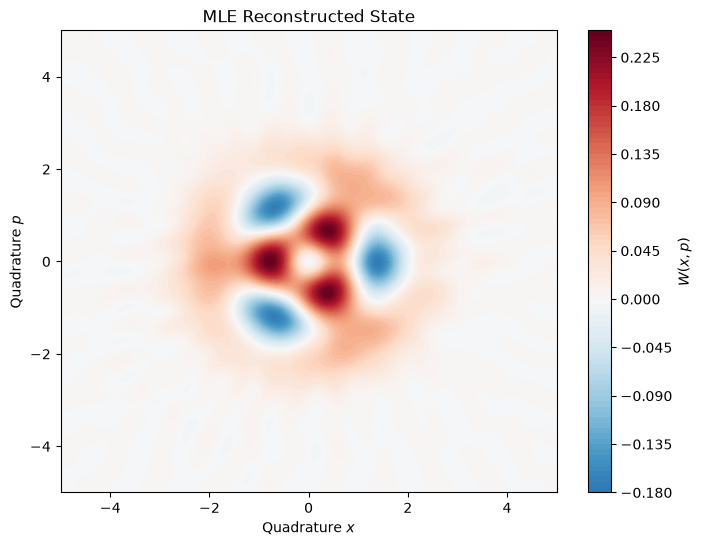

In [12]:
initial_rho = np.zeros((N_cutoff,N_cutoff))
initial_rho[0,0] = 1.0

rho_current = initial_rho
rhos = [rho_current]
fidelities = []
for i in tqdm(range(100)):
    rho_current = MLE_estimator.one_iteration(rho_current)
    rhos.append(rho_current)
    fidelities.append(q.fidelity(q.Qobj(rhos[-1]), q.Qobj(rhos[-2]))**2)
plot_Wigner(q.Qobj(rhos[-1]), xvec=x_array, title='MLE Reconstructed State')